<a href="https://colab.research.google.com/github/11239A086/OpenCV/blob/master/OpenCV_Exercise9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To detect and classify shapes (Triangle, Rectangle, Circle) from an image using OpenCV

Grayscale conversion

Thresholding

Contour detection

Shape approximation

Drawing and labeling

Read the input image.

Convert to grayscale.

Apply Gaussian blur (noise removal).

Apply thresholding.

Detect contours.

Approximate contour shape using approxPolyDP().

Identify shape based on number of sides.

Draw contour and label the shape.

Display output.

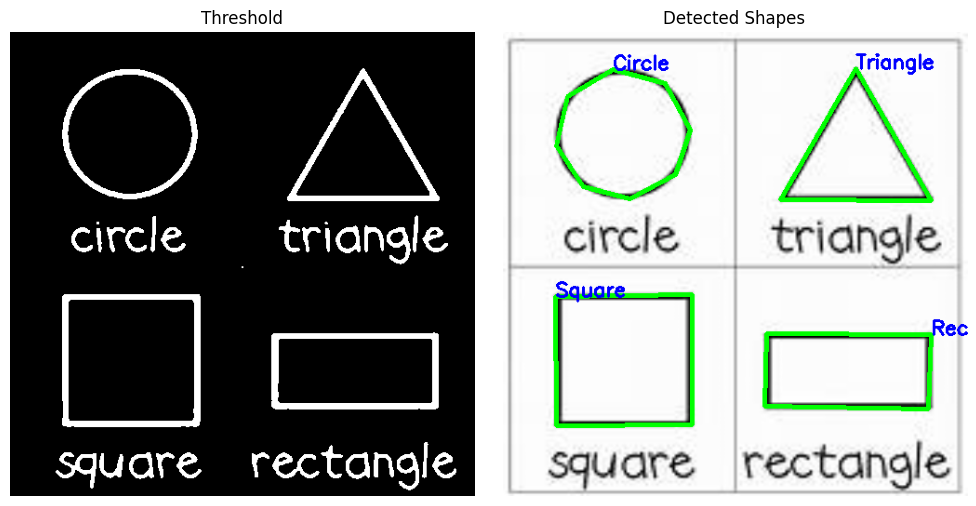

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------- 1. Read Image --------
img = cv2.imread("/content/drive/MyDrive/dataset/shapes.jpg")
img = cv2.resize(img, (500, 500))
output = img.copy()

# -------- 2. Grayscale --------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------- 3. Blur --------
blur = cv2.GaussianBlur(gray, (5,5), 0)

# -------- 4. Threshold --------
_, thresh = cv2.threshold(blur, 150, 255, cv2.THRESH_BINARY_INV)

# -------- 5. Find Contours --------
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# -------- 6. Shape Detection --------
for cnt in contours:
    area = cv2.contourArea(cnt)

    if area < 1000:
        continue

    approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)

    x, y = approx[0][0]

    # -------- Classification --------
    if len(approx) == 3:
        shape = "Triangle"

    elif len(approx) == 4:
        # Use minAreaRect instead of boundingRect
        rect = cv2.minAreaRect(cnt)
        (w, h) = rect[1]

        if h == 0 or w == 0:
            continue

        ratio = w / h if w > h else h / w

        if 0.95 <= ratio <= 1.05:
            shape = "Square"
        else:
            shape = "Rectangle"

    elif len(approx) > 6:
        shape = "Circle"

    else:
        shape = "Other Shape"

    # -------- Draw --------
    cv2.drawContours(output, [approx], -1, (0,255,0), 3)
    cv2.putText(output, shape, (x, y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7, (255,0,0), 2)

# Convert for display
output = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

# -------- Display --------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Threshold")
plt.imshow(thresh, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Detected Shapes")
plt.imshow(output)
plt.axis('off')

plt.tight_layout()
plt.show()